In [6]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [3]:
df=pd.read_csv('uber.csv')
df.head()

,Unnamed: 0,key,fare_amount,pickup_datetime,pickup_longitude,pickup_latitude,dropoff_longitude,dropoff_latitude,passenger_count
0,24238194,2015-05-07 19:52:06.0000003,7.5,2015-05-07 19:52:06 UTC,-73.999817,40.738354,-73.999512,40.723217,1
1,27835199,2009-07-17 20:04:56.0000002,7.7,2009-07-17 20:04:56 UTC,-73.994355,40.728225,-73.994710,40.750325,1
2,44984355,2009-08-24 21:45:00.00000061,12.9,2009-08-24 21:45:00 UTC,-74.005043,40.740770,-73.962565,40.772647,1
3,25894730,2009-06-26 08:22:21.0000001,5.3,2009-06-26 08:22:21 UTC,-73.976124,40.790844,-73.965316,40.803349,3
4,17610152,2014-08-28 17:47:00.000000188,16.0,2014-08-28 17:47:00 UTC,-73.925023,40.744085,-73.973082,40.761247,5


In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 200000 entries, 0 to 199999
Data columns (total 9 columns):
 #   Column             Non-Null Count   Dtype  
---  ------             --------------   -----  
 0   Unnamed: 0         200000 non-null  int64  
 1   key                200000 non-null  object 
 2   fare_amount        200000 non-null  float64
 3   pickup_datetime    200000 non-null  object 
 4   pickup_longitude   200000 non-null  float64
 5   pickup_latitude    200000 non-null  float64
 6   dropoff_longitude  199999 non-null  float64
 7   dropoff_latitude   199999 non-null  float64
 8   passenger_count    200000 non-null  int64  
dtypes: float64(5), int64(2), object(2)
memory usage: 13.7+ MB


In [5]:
df.describe()

,Unnamed: 0,fare_amount,pickup_longitude,pickup_latitude,dropoff_longitude,dropoff_latitude,passenger_count
count,2.000000e+05,200000.000000,200000.000000,200000.000000,199999.000000,199999.000000,200000.000000
mean,2.771250e+07,11.359955,-72.527638,39.935885,-72.525292,39.923890,1.684535
std,1.601382e+07,9.901776,11.437787,7.720539,13.117408,6.794829,1.385997
min,1.000000e+00,-52.000000,-1340.648410,-74.015515,-3356.666300,-881.985513,0.000000
25%,1.382535e+07,6.000000,-73.992065,40.734796,-73.991407,40.733823,1.000000
50%,2.774550e+07,8.500000,-73.981823,40.752592,-73.980093,40.753042,1.000000
75%,4.155530e+07,12.500000,-73.967154,40.767158,-73.963658,40.768001,2.000000
max,5.542357e+07,499.000000,57.418457,1644.421482,1153.572603,872.697628,208.000000


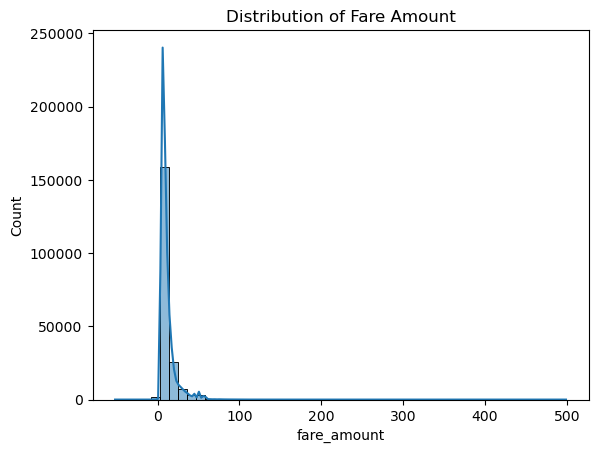

In [7]:
sns.histplot(df['fare_amount'], bins=50, kde=True)
plt.title("Distribution of Fare Amount")
plt.show()

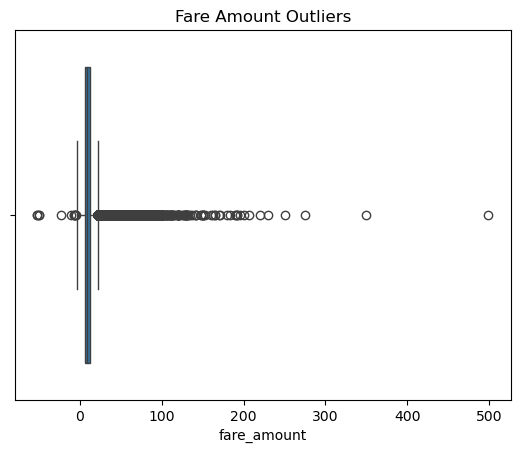

In [8]:
sns.boxplot(x=df['fare_amount'])
plt.title("Fare Amount Outliers")
plt.show()

In [9]:
df.isnull().sum()

Unnamed: 0           0
key                  0
fare_amount          0
pickup_datetime      0
pickup_longitude     0
pickup_latitude      0
dropoff_longitude    1
dropoff_latitude     1
passenger_count      0
dtype: int64

In [10]:
df = df.dropna()

In [12]:
df.isnull().sum()

Unnamed: 0           0
key                  0
fare_amount          0
pickup_datetime      0
pickup_longitude     0
pickup_latitude      0
dropoff_longitude    0
dropoff_latitude     0
passenger_count      0
dtype: int64

In [14]:
df['pickup_datetime'] = pd.to_datetime(df['pickup_datetime'])

df['hour'] = df['pickup_datetime'].dt.hour
df['day'] = df['pickup_datetime'].dt.day
df['month'] = df['pickup_datetime'].dt.month

In [15]:
def time_of_day(hour):
    if hour < 12:
        return "Morning"
    elif hour < 17:
        return "Afternoon"
    elif hour < 21:
        return "Evening"
    else:
        return "Night"

df['time_of_day'] = df['hour'].apply(time_of_day)

In [18]:
from math import radians, sin, cos, sqrt, atan2

In [19]:
def calculate_distance(lat1, lon1, lat2, lon2):
    R = 6371  # Earth radius in km
    
    lat1 = radians(lat1)
    lon1 = radians(lon1)
    lat2 = radians(lat2)
    lon2 = radians(lon2)

    dlon = lon2 - lon1
    dlat = lat2 - lat1

    a = sin(dlat/2)**2 + cos(lat1) * cos(lat2) * sin(dlon/2)**2
    c = 2 * atan2(sqrt(a), sqrt(1-a))

    distance = R * c
    return distance

In [20]:
df['distance_km'] = df.apply(
    lambda row: calculate_distance(
        row['pickup_latitude'],
        row['pickup_longitude'],
        row['dropoff_latitude'],
        row['dropoff_longitude']
    ),
    axis=1
)

In [21]:
def distance_category(d):
    if d < 2:
        return "Short"
    elif d < 10:
        return "Medium"
    else:
        return "Long"

df['distance_category'] = df['distance_km'].apply(distance_category)

In [22]:
X = df[['distance_km','passenger_count','pickup_latitude',
        'pickup_longitude','dropoff_latitude','dropoff_longitude']]

y = df['fare_amount']

In [23]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,   # 20% testing data
    random_state=42
)

In [24]:
print("Training Data:", X_train.shape)
print("Testing Data:", X_test.shape)

Training Data: (159999, 6)
Testing Data: (40000, 6)


In [26]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [27]:
print(X_train_scaled[:5])

[[-4.91694720e-02 -4.87423280e-01  1.03332811e-01 -1.28064758e-01
   1.18661638e-01 -1.07482689e-01]
 [-4.95244919e-02 -4.87423280e-01  1.00917117e-01 -1.29540737e-01
   1.16779636e-01 -1.07825111e-01]
 [-5.08797656e-02  9.36234062e-01  1.04754546e-01 -1.28144734e-01
   1.23850603e-01 -1.06950490e-01]
 [-5.32854705e-02  2.24405391e-01  1.04912475e-01 -1.24889111e-01
   1.22849465e-01 -1.05397558e-01]
 [-2.08991915e-03  2.35989140e+00  1.01271649e-01 -1.26458250e-01
   1.03968877e-01 -9.22050065e-02]]


In [31]:
corr_matrix = df.corr(numeric_only=True)
print(corr_matrix)

                   Unnamed: 0  fare_amount  pickup_longitude  pickup_latitude  \
Unnamed: 0           1.000000     0.000587          0.000230        -0.000341   
fare_amount          0.000587     1.000000          0.010458        -0.008482   
pickup_longitude     0.000230     0.010458          1.000000        -0.816461   
pickup_latitude     -0.000341    -0.008482         -0.816461         1.000000   
dropoff_longitude    0.000270     0.008986          0.833026        -0.774787   
dropoff_latitude     0.000271    -0.011014         -0.846324         0.702367   
passenger_count      0.002259     0.010158         -0.000415        -0.001559   
hour                 0.000044    -0.021463          0.002432        -0.003821   
day                  0.000556     0.001384          0.005183        -0.008263   
month                0.001299     0.023813         -0.004665         0.004625   
distance_km         -0.000918     0.024684          0.105581        -0.062436   

                   dropoff_

In [32]:
corr_matrix = df[['fare_amount','passenger_count','pickup_latitude',
                  'pickup_longitude','dropoff_latitude',
                  'dropoff_longitude','distance_km']].corr()

print(corr_matrix)

                   fare_amount  passenger_count  pickup_latitude  \
fare_amount           1.000000         0.010158        -0.008482   
passenger_count       0.010158         1.000000        -0.001559   
pickup_latitude      -0.008482        -0.001559         1.000000   
pickup_longitude      0.010458        -0.000415        -0.816461   
dropoff_latitude     -0.011014        -0.000659         0.702367   
dropoff_longitude     0.008986         0.000033        -0.774787   
distance_km           0.024684        -0.001472        -0.062436   

                   pickup_longitude  dropoff_latitude  dropoff_longitude  \
fare_amount                0.010458         -0.011014           0.008986   
passenger_count           -0.000415         -0.000659           0.000033   
pickup_latitude           -0.816461          0.702367          -0.774787   
pickup_longitude           1.000000         -0.846324           0.833026   
dropoff_latitude          -0.846324          1.000000          -0.917010   

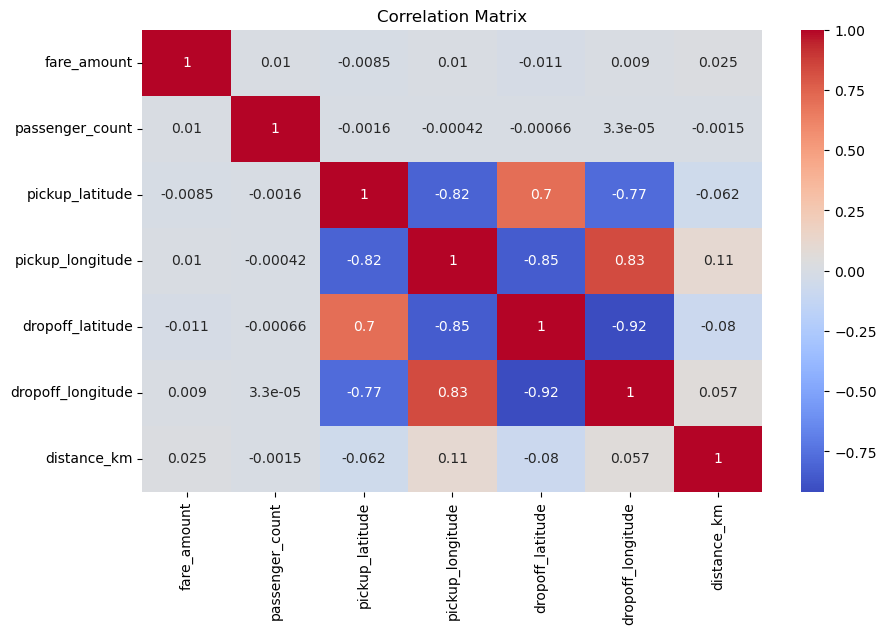

In [33]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(10,6))
sns.heatmap(corr_matrix, annot=True, cmap="coolwarm")
plt.title("Correlation Matrix")
plt.show()

In [34]:
from sklearn.linear_model import LinearRegression


In [36]:
model = LinearRegression()
model.fit(X_train_scaled, y_train)

,fit_intercept,True
,copy_X,True
,tol,1e-06
,n_jobs,None
,positive,False


In [37]:
predictions = model.predict(X_test_scaled)

In [38]:
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

In [39]:
mae = mean_absolute_error(y_test, predictions)
mse = mean_squared_error(y_test, predictions)
rmse = mse ** 0.5
r2 = r2_score(y_test, predictions)

print("MAE:", mae)
print("MSE:", mse)
print("RMSE:", rmse)
print("R2 Score:", r2)

MAE: 6.069622126223882
MSE: 103.9609080478705
RMSE: 10.19612220640134
R2 Score: 0.0006058803601811658


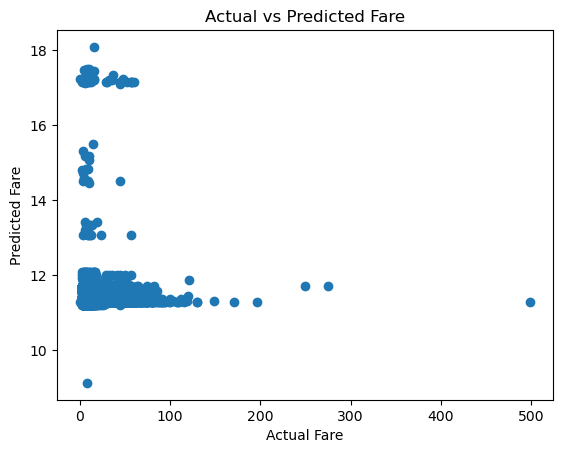

In [40]:
import matplotlib.pyplot as plt

plt.scatter(y_test, predictions)
plt.xlabel("Actual Fare")
plt.ylabel("Predicted Fare")
plt.title("Actual vs Predicted Fare")
plt.show()

In [41]:
from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import GridSearchCV

In [42]:
model = RandomForestRegressor()

In [43]:
param_grid = {
    'n_estimators': [50, 100],
    'max_depth': [5, 10, 15],
    'min_samples_split': [2, 5]
}

In [ ]:
grid_search = GridSearchCV(
    estimator=model,
    param_grid=param_grid,
    cv=3,
    scoring='r2'
)

grid_search.fit(X_train_scaled, y_train)

In [ ]:
print("Best Parameters:", grid_search.best_params_)

In [ ]:
best_model = grid_search.best_estimator_
predictions = best_model.predict(X_test_scaled)